Black-Scholes Closed-Form Formula

In [1]:
import math
import scipy as sp
from scipy.stats import norm


sigma = 0.2
r = 0.005
K = 100
T = 1  #years
S = 100
c = r + 0.5 * sigma**2
 
d1 = (math.log(S/K) + c*T)/(sigma * math.sqrt(T))
d2 = d1 - sigma * math.sqrt(T)


Nd1 = norm.cdf(d1)
Nd2 = norm.cdf(d2)


c = S * Nd1 - K * math.exp(-r*T) * Nd2

print("Option price at S=100:", c)


Option price at S=100: 8.19755391024669


Explicit Finite Difference PDE Solver

Option price at S=100: 8.19130394111668


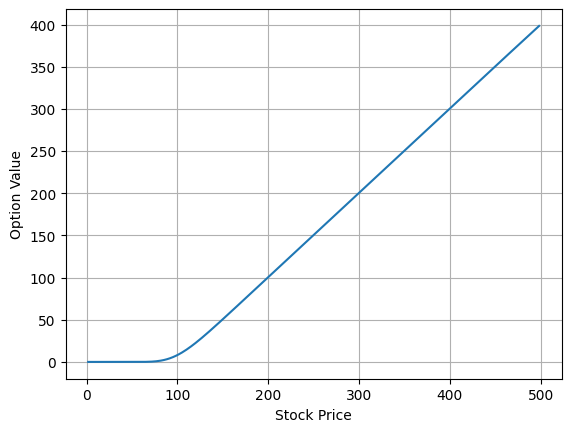

In [17]:
import numpy as np
import matplotlib.pyplot as plt

sigma = 0.2
r = 0.005
K = 100
T = 1  #years





S_min = 1e-3
S_max = 500



Ns = 300
S = np.linspace(S_min, S_max, Ns+1)
S_int = S[1:-1]
ds = (S_max - S_min) / Ns

dt = 0.4 * ds**2 / (sigma**2 * S_max**2)
Nt = int(T / dt) + 1
dt = T / Nt


t = dt * np.arange(Nt + 1)  


tau = T - t

V_left  = 0
V_right = S_max - K*np.exp(-r*tau)



V = np.zeros((Ns - 1, Nt + 1))
V[:, 0] = np.maximum(S_int - K, 0)


for n in range(Nt):

    beta = V_right[n]

    for i in range(Ns-1):

        S_i = S_int[i]

        A = 0.5 * sigma**2 * S_i**2 * dt / ds**2
        B = r * S_i * dt / (2*ds)

        if i == 0:
            V[i,n+1] = V[i,n] + A*(V[i+1,n] - 2*V[i,n] + V_left) + B*(V[i+1,n] - V_left) - r*dt*V[i,n]

        elif i < Ns-2:
            V[i,n+1] = V[i,n] + A*(V[i+1,n] - 2*V[i,n] + V[i-1,n]) + B*(V[i+1,n] - V[i-1,n]) - r*dt*V[i,n]

        else:
            V[i,n+1] = V[i,n] + A*(beta - 2*V[i,n] + V[i-1,n]) + B*(beta - V[i-1,n]) - r*dt*V[i,n]


idx = np.argmin(np.abs(S_int - 100))
c = V[idx, -1]

print("Option price at S=100:", c)



plt.plot(S_int, V[:, -1])
plt.xlabel("Stock Price")
plt.ylabel("Option Value")
plt.grid()
plt.show()






Call price = 8.195102560794558


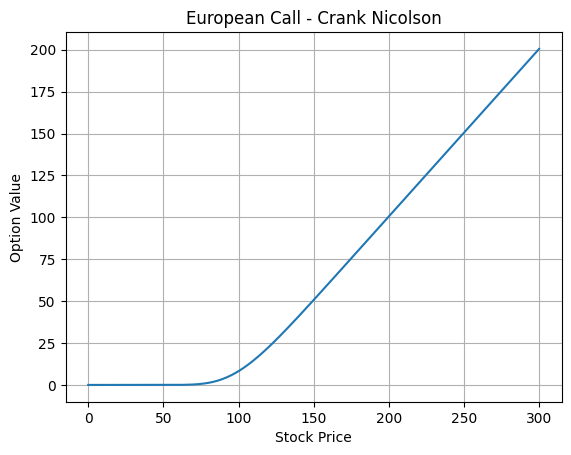

In [18]:
import numpy as np
import matplotlib.pyplot as plt

sigma = 0.2
r = 0.005
K = 100
T = 1  #years
Ns =300


Smax = 300
ds = Smax / Ns

S = np.linspace(0, Smax, Ns + 1)
Nt = 1000

dt = T/Nt



i = np.arange(1, Ns)

a = 0.25 * dt * (sigma**2 * i**2 - r*i)
b = -0.5 * dt * (sigma**2 * i**2 + r)
c = 0.25 * dt * (sigma**2 * i**2 + r*i)

A = np.zeros((Ns-1,Ns-1))
B = np.zeros((Ns-1,Ns-1))

A = np.diag(1 - b)
A += np.diag(-c[:-1], 1)
A += np.diag(-a[1:], -1)

B = np.diag(1 + b)
B += np.diag(c[:-1], 1)
B += np.diag(a[1:], -1)


V = np.maximum(S - K, 0)
Vint = V[1:-1]


for n in range(Nt):
   
    tau_old = n * dt
    tau_new = (n + 1) * dt

   
    V_left_old  = 0
    V_left_new  = 0

   
    V_right_old = Smax - K * np.exp(-r * tau_old)
    V_right_new = Smax - K * np.exp(-r * tau_new)
    
    rhs = B @ Vint
    
   
    rhs[0]  += a[0] * (V_left_old + V_left_new)
    rhs[-1] += c[-1] * (V_right_old + V_right_new)

    Vint = np.linalg.solve(A, rhs)

V = np.zeros(Ns + 1)

V[0] = 0
V[-1] = Smax - K*np.exp(-r*T)

V[1:-1] = Vint


S0 = 100

price = np.interp(S0, S, V)

print("Call price =", price)

plt.plot(S, V)
plt.xlabel("Stock Price")
plt.ylabel("Option Value")
plt.title("European Call - Crank Nicolson")
plt.grid()
plt.show()

